<a href="https://colab.research.google.com/github/jj-practice-star/Data-Science-Projects-Sem7/blob/main/Lab4_FDS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler , StandardScaler
from scipy import stats
import seaborn as sns
import matplotlib.pyplot as plt
df=pd.read_csv('Hotel_Reviews.csv')
df.head()

,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [ ]:
print("------------------------Shape----------------------------")
print(df.shape)
print("------------------------Types----------------------------")
print(df.dtypes)
print("------------------------Describe----------------------------")
df.describe()

------------------------Shape----------------------------
(515738, 17)
------------------------Types----------------------------
Hotel_Address                                  object
Additional_Number_of_Scoring                    int64
Review_Date                                    object
Average_Score                                 float64
Hotel_Name                                     object
Reviewer_Nationality                           object
Negative_Review                                object
Review_Total_Negative_Word_Counts               int64
Total_Number_of_Reviews                         int64
Positive_Review                                object
Review_Total_Positive_Word_Counts               int64
Total_Number_of_Reviews_Reviewer_Has_Given      int64
Reviewer_Score                                float64
Tags                                           object
days_since_review                              object
lat                                           float64
lng    

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
count,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,512470.000000,512470.000000
mean,498.081836,8.397487,18.539450,2743.743944,17.776458,7.166001,8.395077,49.442439,2.823803
std,500.538467,0.548048,29.690831,2317.464868,21.804185,11.040228,1.637856,3.466325,4.579425
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214662,-0.143372
50%,341.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,0.010607
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233


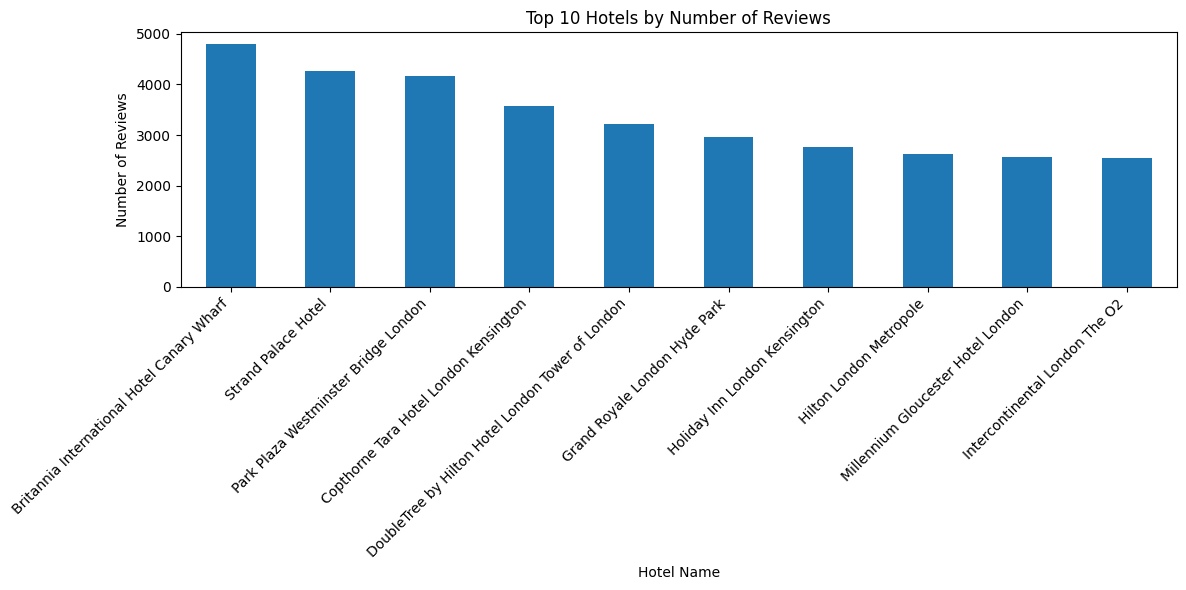

In [ ]:
import matplotlib.pyplot as plt

# Count number of records/reviews for each hotel
top_hotels = df['Hotel_Name'].value_counts().head(10)

# Plot bar graph
plt.figure(figsize=(12, 6))
top_hotels.plot(kind='bar')

plt.title('Top 10 Hotels by Number of Reviews')
plt.xlabel('Hotel Name')
plt.ylabel('Number of Reviews')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()

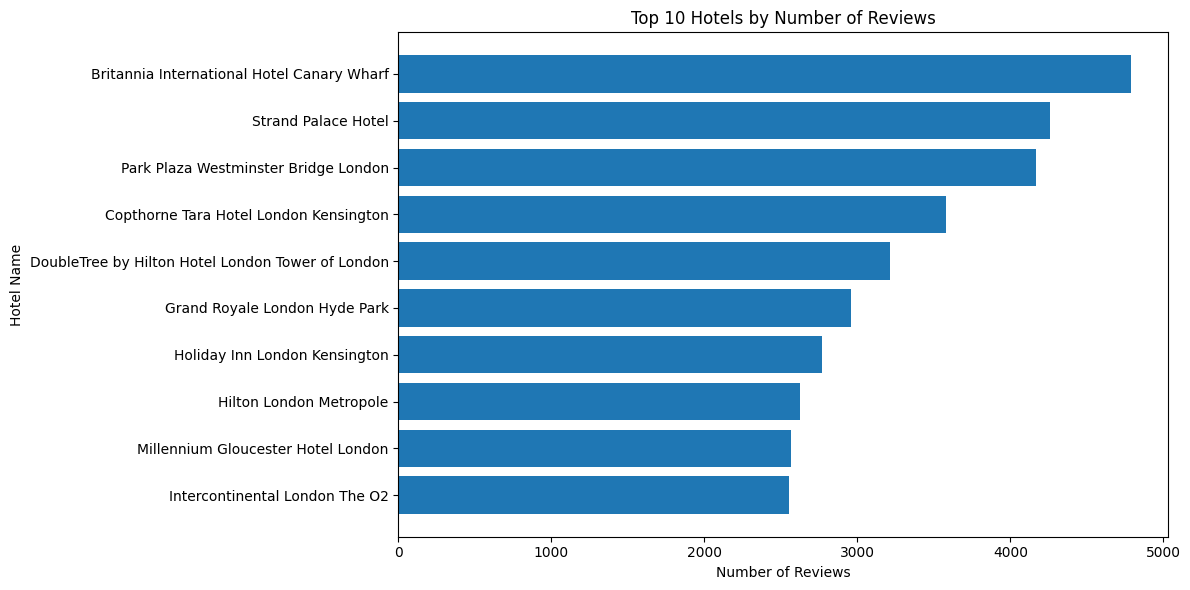

In [ ]:
import matplotlib.pyplot as plt

top_hotels = df['Hotel_Name'].value_counts().head(10)

plt.figure(figsize=(12, 6))
plt.barh(top_hotels.index, top_hotels.values)

plt.title('Top 10 Hotels by Number of Reviews')
plt.xlabel('Number of Reviews')
plt.ylabel('Hotel Name')

# Put the hotel with the highest count at the top
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

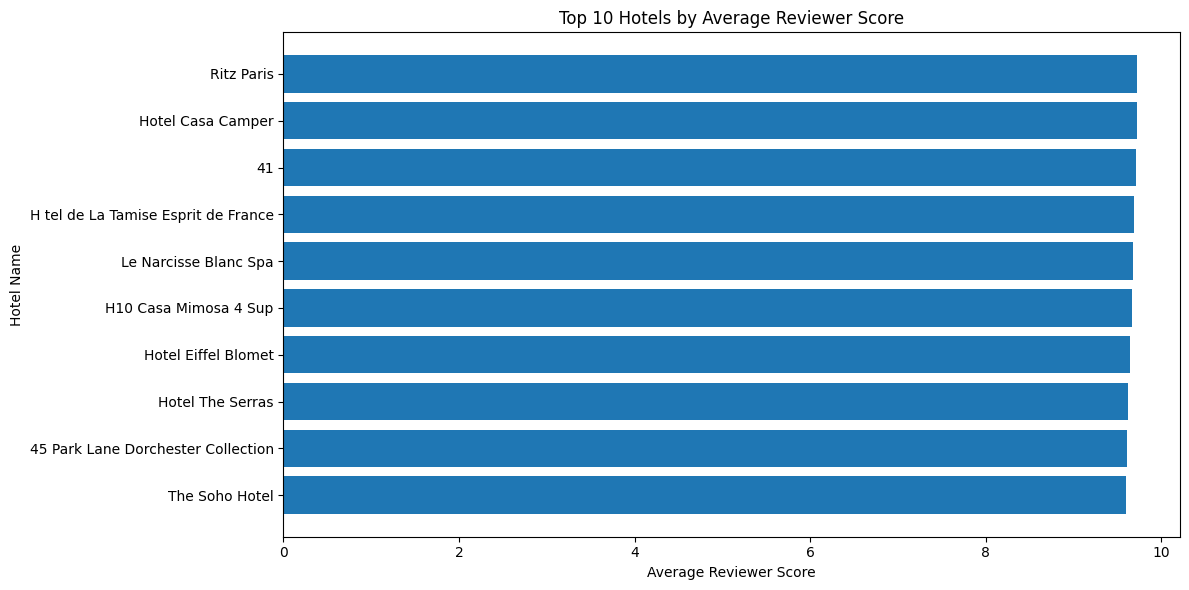

In [ ]:
hotel_reviewer_score = (
    df.groupby('Hotel_Name')['Reviewer_Score']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12, 6))
plt.barh(hotel_reviewer_score.index, hotel_reviewer_score.values)

plt.title('Top 10 Hotels by Average Reviewer Score')
plt.xlabel('Average Reviewer Score')
plt.ylabel('Hotel Name')

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

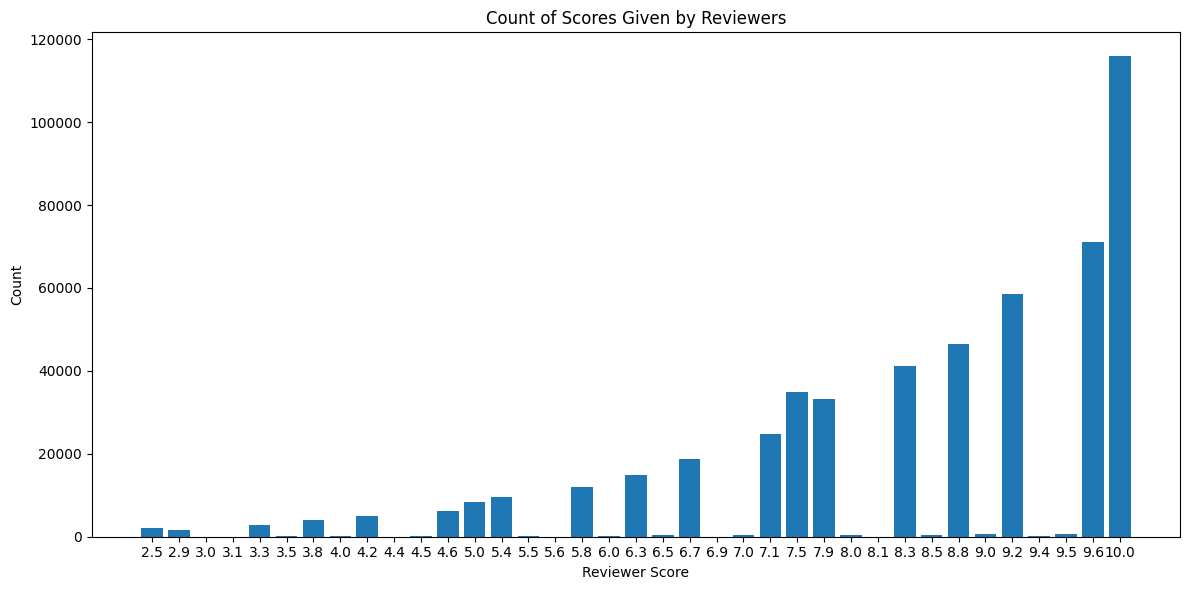

In [ ]:
import matplotlib.pyplot as plt

# Count how many times each score was given
score_count = df['Reviewer_Score'].value_counts().sort_index()

# Plot
plt.figure(figsize=(12, 6))
plt.bar(score_count.index.astype(str), score_count.values)

plt.title('Count of Scores Given by Reviewers')
plt.xlabel('Reviewer Score')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("jiashenliu/515k-hotel-reviews-data-in-europe")

print("Path to dataset files:", path)

100%|██████████| 45.1M/45.1M [00:00<00:00, 122MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jiashenliu/515k-hotel-reviews-data-in-europe/versions/1


In [ ]:
import kagglehub
import pandas as pd
import os

path = kagglehub.dataset_download(
    "jiashenliu/515k-hotel-reviews-data-in-europe"
)

# Find CSV files
csv_files = [
    os.path.join(path, f)
    for f in os.listdir(path)
    if f.endswith(".csv")
]

df = pd.read_csv(csv_files[0])

df.head()

Using Colab cache for faster access to the '515k-hotel-reviews-data-in-europe' dataset.


,Hotel_Address,Additional_Number_of_Scoring,Review_Date,Average_Score,Hotel_Name,Reviewer_Nationality,Negative_Review,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Positive_Review,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,Tags,days_since_review,lat,lng
0,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Russia,I am so angry that i made this post available...,397,1403,Only the park outside of the hotel was beauti...,11,7,2.9,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
1,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,8/3/2017,7.7,Hotel Arena,Ireland,No Negative,0,1403,No real complaints the hotel was great great ...,105,7,7.5,"[' Leisure trip ', ' Couple ', ' Duplex Double...",0 days,52.360576,4.915968
2,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,Australia,Rooms are nice but for elderly a bit difficul...,42,1403,Location was good and staff were ok It is cut...,21,9,7.1,"[' Leisure trip ', ' Family with young childre...",3 days,52.360576,4.915968
3,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/31/2017,7.7,Hotel Arena,United Kingdom,My room was dirty and I was afraid to walk ba...,210,1403,Great location in nice surroundings the bar a...,26,1,3.8,"[' Leisure trip ', ' Solo traveler ', ' Duplex...",3 days,52.360576,4.915968
4,s Gravesandestraat 55 Oost 1092 AA Amsterdam ...,194,7/24/2017,7.7,Hotel Arena,New Zealand,You When I booked with your company on line y...,140,1403,Amazing location and building Romantic setting,8,3,6.7,"[' Leisure trip ', ' Couple ', ' Suite ', ' St...",10 days,52.360576,4.915968


In [ ]:


print(df.shape)
print(df.columns)
print(df.head())

(515738, 17)
Index(['Hotel_Address', 'Additional_Number_of_Scoring', 'Review_Date',
       'Average_Score', 'Hotel_Name', 'Reviewer_Nationality',
       'Negative_Review', 'Review_Total_Negative_Word_Counts',
       'Total_Number_of_Reviews', 'Positive_Review',
       'Review_Total_Positive_Word_Counts',
       'Total_Number_of_Reviews_Reviewer_Has_Given', 'Reviewer_Score', 'Tags',
       'days_since_review', 'lat', 'lng'],
      dtype='object')
                                       Hotel_Address  \
0   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
1   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
2   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
3   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   
4   s Gravesandestraat 55 Oost 1092 AA Amsterdam ...   

   Additional_Number_of_Scoring Review_Date  Average_Score   Hotel_Name  \
0                           194    8/3/2017            7.7  Hotel Arena   
1                           194    8/3/2017            7.7  Hot

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 515738 entries, 0 to 515737
Data columns (total 17 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   Hotel_Address                               515738 non-null  object 
 1   Additional_Number_of_Scoring                515738 non-null  int64  
 2   Review_Date                                 515738 non-null  object 
 3   Average_Score                               515738 non-null  float64
 4   Hotel_Name                                  515738 non-null  object 
 5   Reviewer_Nationality                        515738 non-null  object 
 6   Negative_Review                             515738 non-null  object 
 7   Review_Total_Negative_Word_Counts           515738 non-null  int64  
 8   Total_Number_of_Reviews                     515738 non-null  int64  
 9   Positive_Review                             515738 non-null  object 
 

In [ ]:
df.describe()

,Additional_Number_of_Scoring,Average_Score,Review_Total_Negative_Word_Counts,Total_Number_of_Reviews,Review_Total_Positive_Word_Counts,Total_Number_of_Reviews_Reviewer_Has_Given,Reviewer_Score,lat,lng
count,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,515738.000000,512470.000000,512470.000000
mean,498.081836,8.397487,18.539450,2743.743944,17.776458,7.166001,8.395077,49.442439,2.823803
std,500.538467,0.548048,29.690831,2317.464868,21.804185,11.040228,1.637856,3.466325,4.579425
min,1.000000,5.200000,0.000000,43.000000,0.000000,1.000000,2.500000,41.328376,-0.369758
25%,169.000000,8.100000,2.000000,1161.000000,5.000000,1.000000,7.500000,48.214662,-0.143372
50%,341.000000,8.400000,9.000000,2134.000000,11.000000,3.000000,8.800000,51.499981,0.010607
75%,660.000000,8.800000,23.000000,3613.000000,22.000000,8.000000,9.600000,51.516288,4.834443
max,2682.000000,9.800000,408.000000,16670.000000,395.000000,355.000000,10.000000,52.400181,16.429233


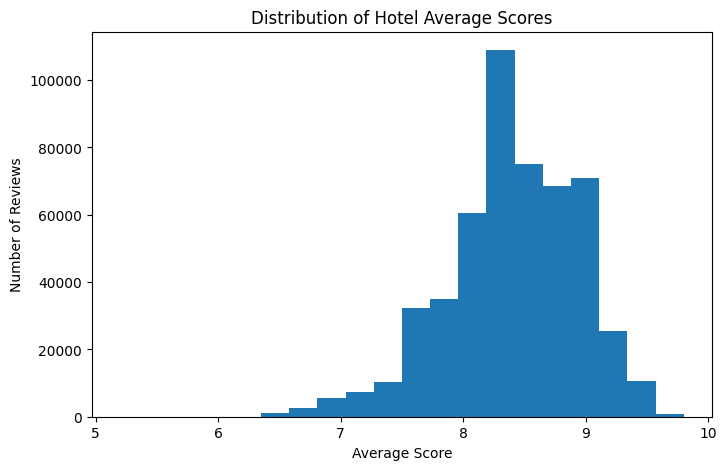

In [ ]:
#A. Distribution of Hotel Scores
plt.figure(figsize=(8,5))

plt.hist(df["Average_Score"], bins=20)

plt.xlabel("Average Score")
plt.ylabel("Number of Reviews")
plt.title("Distribution of Hotel Average Scores")

plt.show()

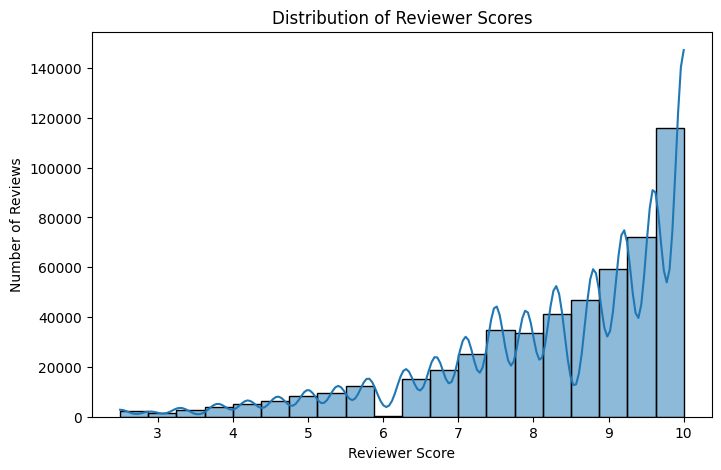

In [ ]:
#B. Reviewer Score Distribution
plt.figure(figsize=(8,5))

sns.histplot(df["Reviewer_Score"], bins=20, kde=True)

plt.title("Distribution of Reviewer Scores")
plt.xlabel("Reviewer Score")
plt.ylabel("Number of Reviews")

plt.show()

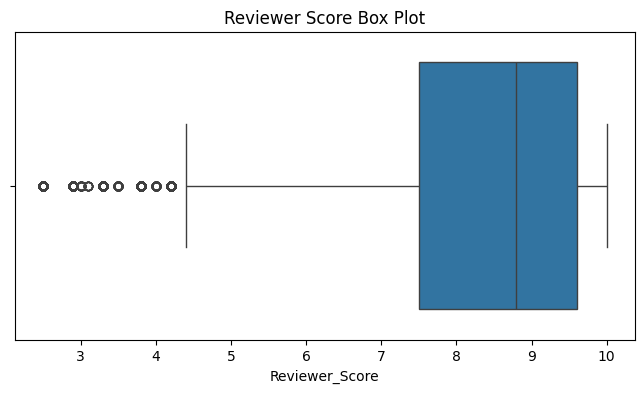

In [ ]:
#3. Box Plot — Detect Outliers
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Reviewer_Score"])

plt.title("Reviewer Score Box Plot")

plt.show()

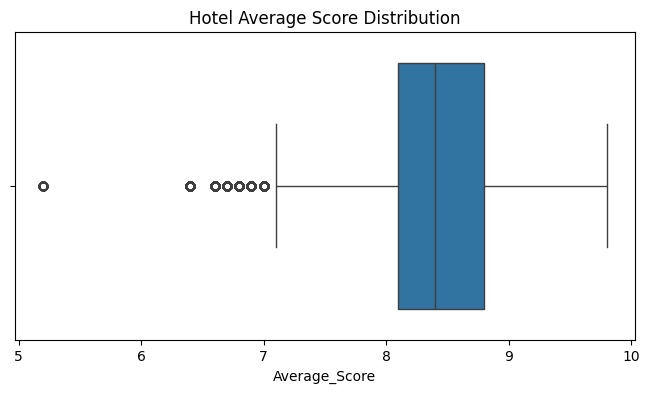

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["Average_Score"])

plt.title("Hotel Average Score Distribution")

plt.show()

In [ ]:
#Categorical Feature — Reviewer Nationality
top_nationalities = df["Reviewer_Nationality"].value_counts().head(10)

print(top_nationalities)

Reviewer_Nationality
United Kingdom               245246
United States of America      35437
Australia                     21686
Ireland                       14827
United Arab Emirates          10235
Saudi Arabia                   8951
Netherlands                    8772
Switzerland                    8678
Germany                        7941
Canada                         7894
Name: count, dtype: int64


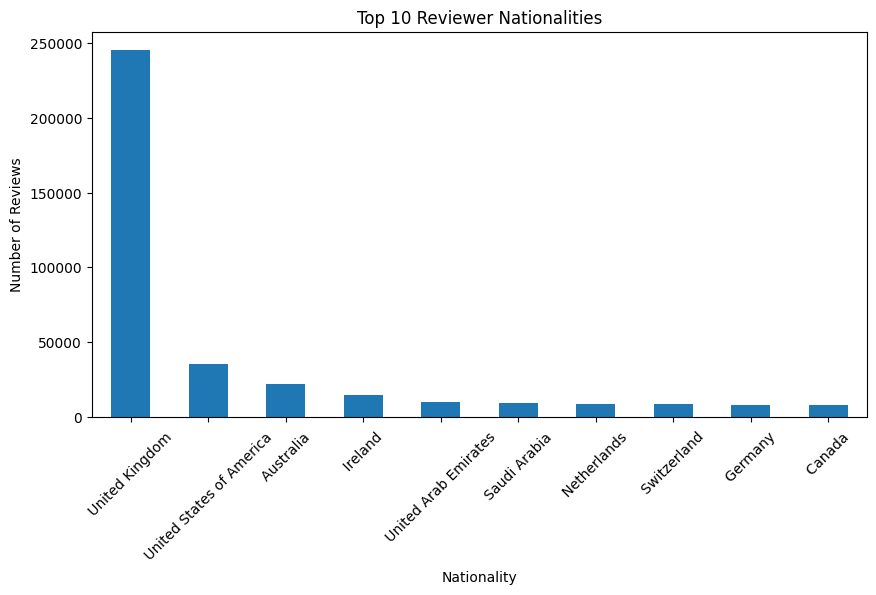

In [ ]:
plt.figure(figsize=(10,5))

top_nationalities.plot(kind="bar")

plt.title("Top 10 Reviewer Nationalities")
plt.xlabel("Nationality")
plt.ylabel("Number of Reviews")

plt.xticks(rotation=45)

plt.show()

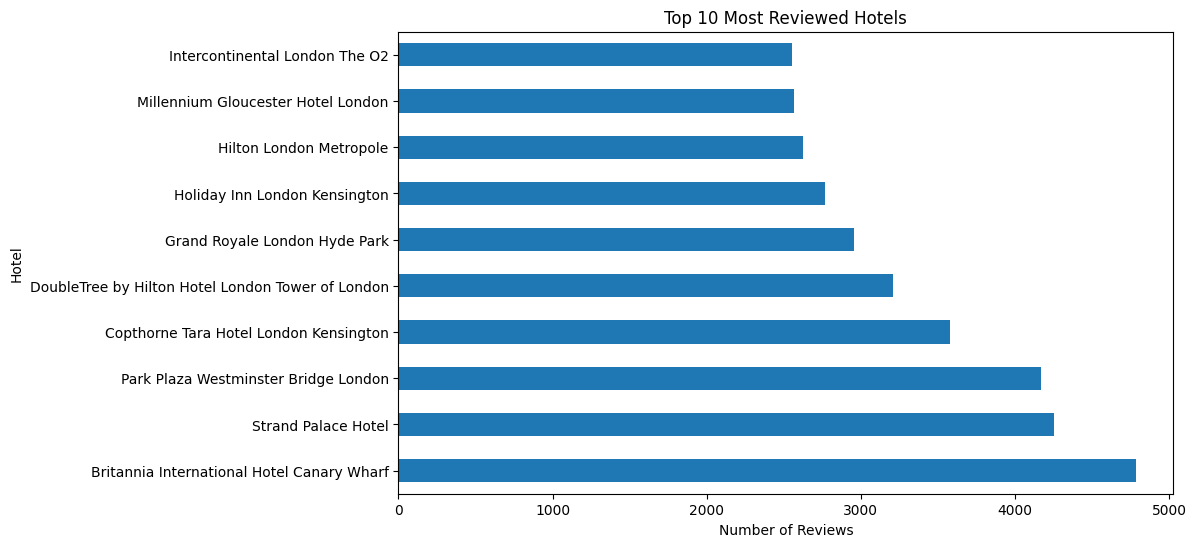

In [ ]:
#5. Top 10 Hotels by Number of Reviews
top_hotels = df["Hotel_Name"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_hotels.plot(kind="barh")

plt.title("Top 10 Most Reviewed Hotels")
plt.xlabel("Number of Reviews")
plt.ylabel("Hotel")

plt.show()

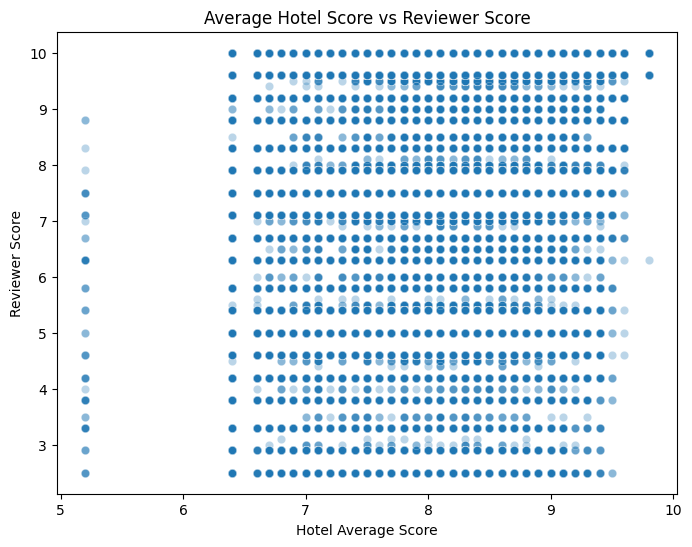

In [ ]:
#Relationship Between Two Numerical Features
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="Average_Score",
    y="Reviewer_Score",
    alpha=0.3
)

plt.title("Average Hotel Score vs Reviewer Score")
plt.xlabel("Hotel Average Score")
plt.ylabel("Reviewer Score")

plt.show()


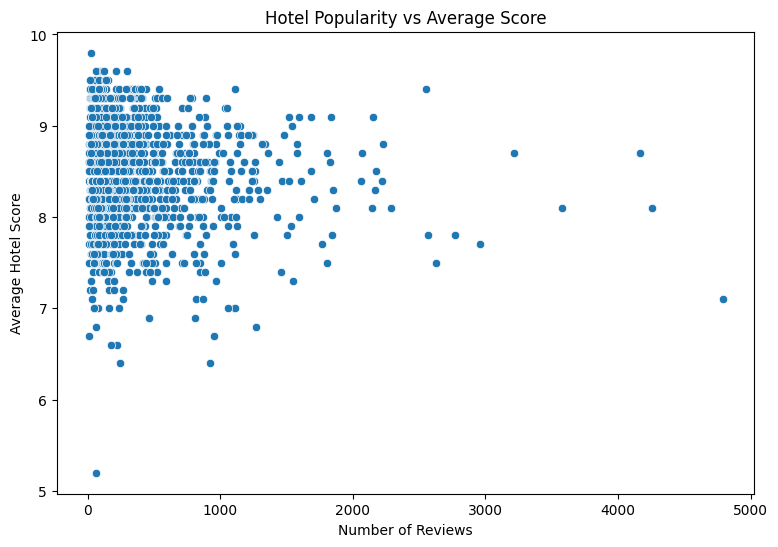

In [ ]:
#7. Average Score vs Number of Reviews
hotel_reviews = (
    df.groupby("Hotel_Name")
      .size()
      .reset_index(name="Review_Count")
)
hotel_data = df.groupby("Hotel_Name").agg(
    Average_Score=("Average_Score", "first"),
    Review_Count=("Reviewer_Score", "count")
).reset_index()
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=hotel_data,
    x="Review_Count",
    y="Average_Score"
)

plt.title("Hotel Popularity vs Average Score")
plt.xlabel("Number of Reviews")
plt.ylabel("Average Hotel Score")

plt.show()

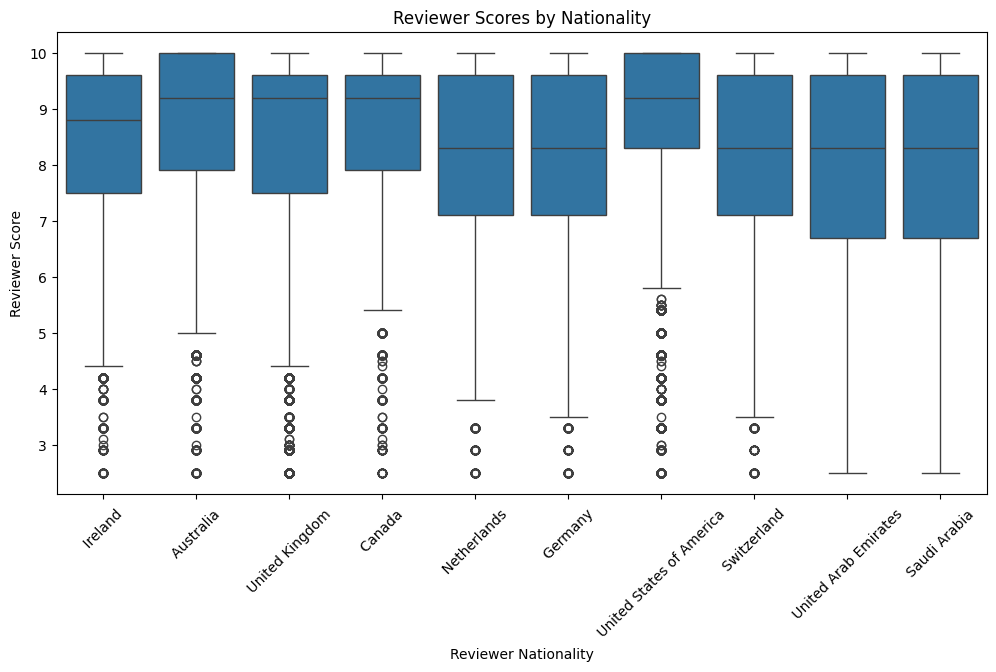

In [ ]:
top10 = df["Reviewer_Nationality"].value_counts().head(10).index

nationality_data = df[
    df["Reviewer_Nationality"].isin(top10)
]
plt.figure(figsize=(12,6))

sns.boxplot(
    data=nationality_data,
    x="Reviewer_Nationality",
    y="Reviewer_Score"
)

plt.xticks(rotation=45)

plt.title("Reviewer Scores by Nationality")
plt.xlabel("Reviewer Nationality")
plt.ylabel("Reviewer Score")

plt.show()

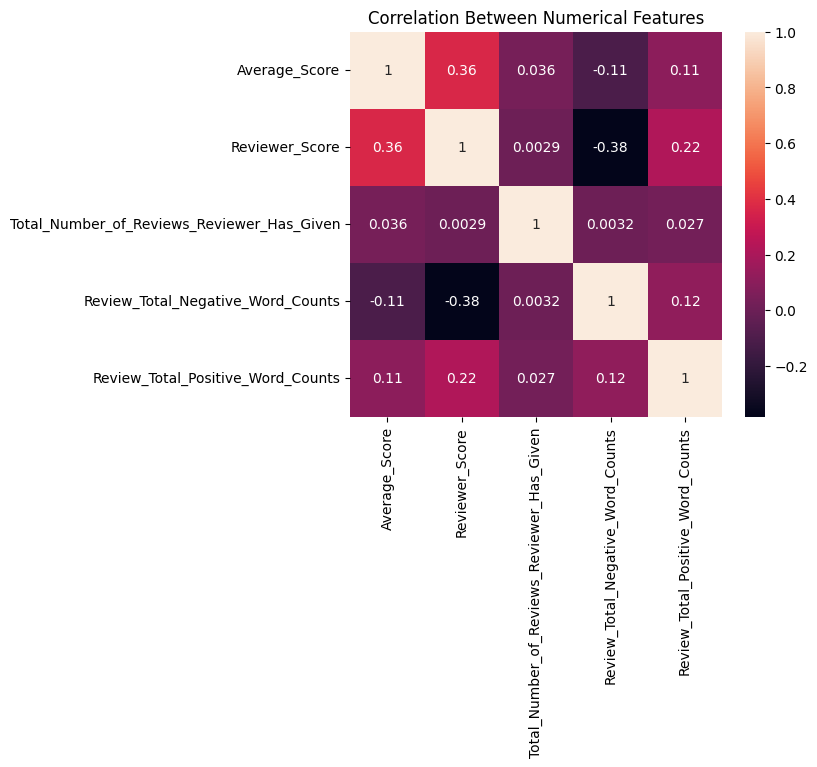

In [ ]:
#Hotel Score vs Reviewer Score — Correlation
df[["Average_Score", "Reviewer_Score"]].corr()
plt.figure(figsize=(6,5))

sns.heatmap(
    df[[
        "Average_Score",
        "Reviewer_Score",
        "Total_Number_of_Reviews_Reviewer_Has_Given",
        "Review_Total_Negative_Word_Counts",
        "Review_Total_Positive_Word_Counts"
    ]].corr(),
    annot=True
)

plt.title("Correlation Between Numerical Features")

plt.show()

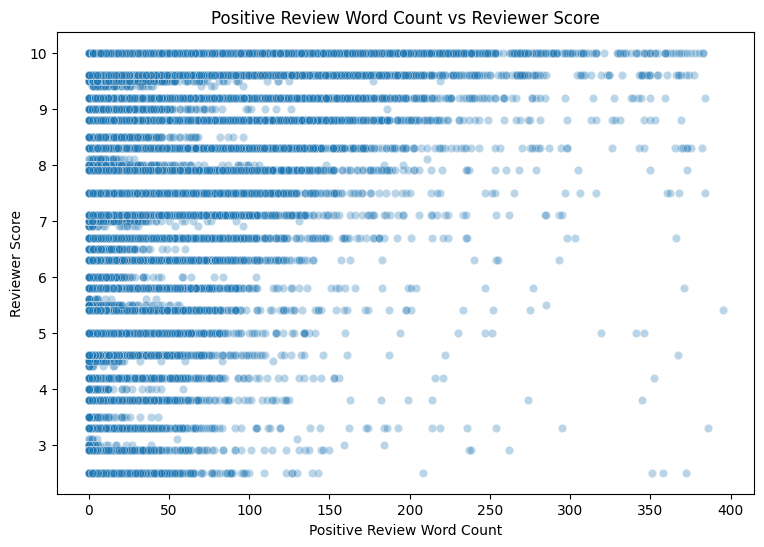

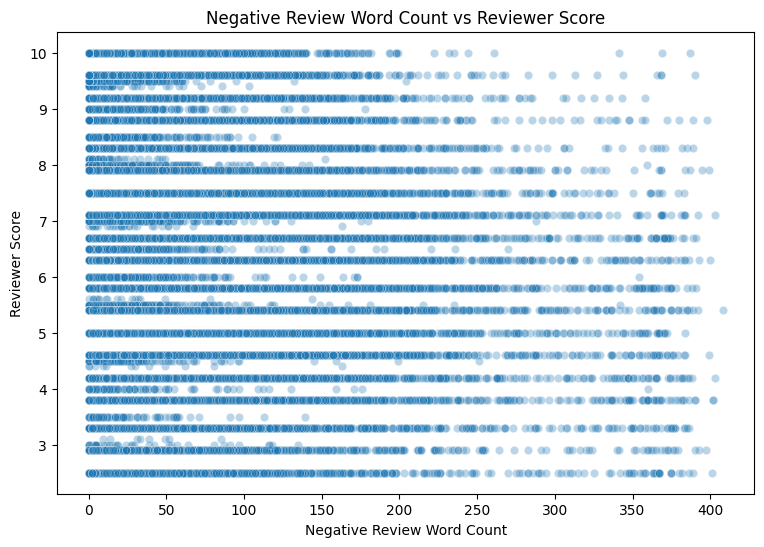

In [ ]:
#10. Positive vs Negative Review Word Counts
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Review_Total_Positive_Word_Counts",
    y="Reviewer_Score",
    alpha=0.3
)

plt.title("Positive Review Word Count vs Reviewer Score")
plt.xlabel("Positive Review Word Count")
plt.ylabel("Reviewer Score")

plt.show()
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Review_Total_Negative_Word_Counts",
    y="Reviewer_Score",
    alpha=0.3
)

plt.title("Negative Review Word Count vs Reviewer Score")
plt.xlabel("Negative Review Word Count")
plt.ylabel("Reviewer Score")

plt.show()

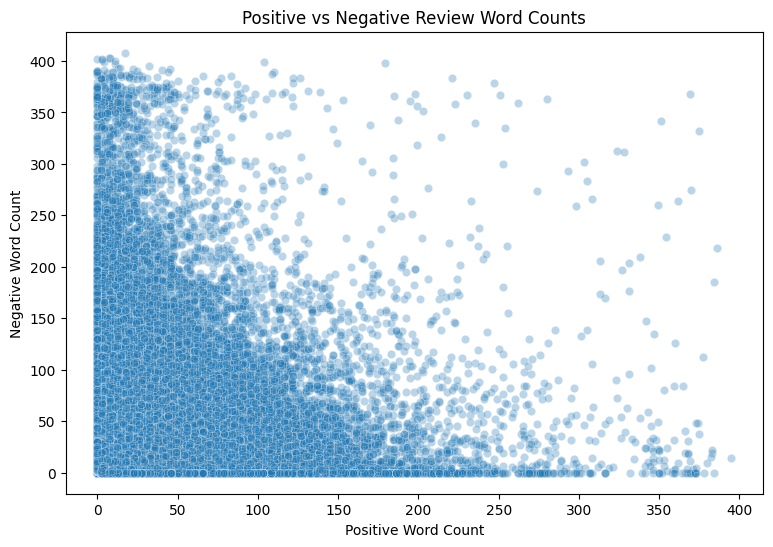

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Review_Total_Positive_Word_Counts",
    y="Review_Total_Negative_Word_Counts",
    alpha=0.3
)

plt.title("Positive vs Negative Review Word Counts")

plt.xlabel("Positive Word Count")
plt.ylabel("Negative Word Count")

plt.show()

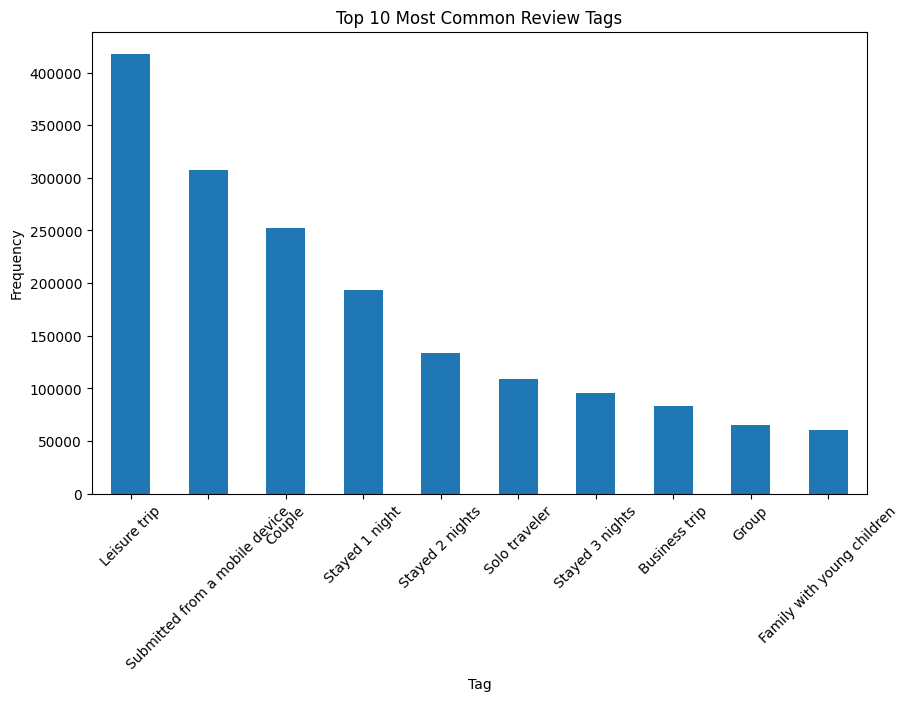

In [ ]:
#Review Score by Trip Type
from ast import literal_eval

df["Tags"] = df["Tags"].apply(literal_eval)
tags = df.explode("Tags")

tags["Tags"] = tags["Tags"].str.strip()
tags["Tags"].value_counts().head(15)
top_tags = tags["Tags"].value_counts().head(10)

plt.figure(figsize=(10,6))

top_tags.plot(kind="bar")

plt.title("Top 10 Most Common Review Tags")
plt.xlabel("Tag")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

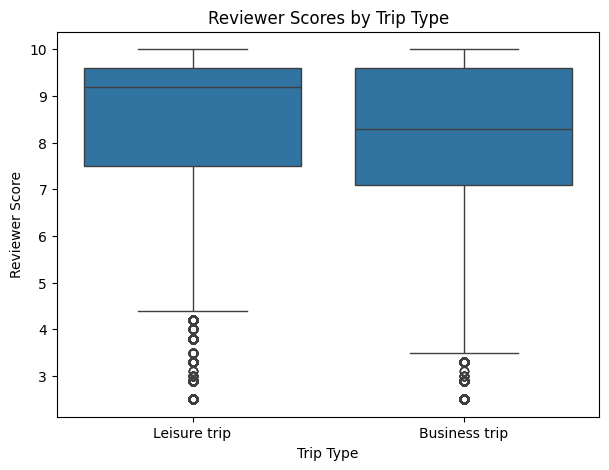

In [ ]:
#13. Trip Type vs Reviewer Score
trip_types = tags[
    tags["Tags"].isin([
        "Leisure trip",
        "Business trip"
    ])
]
plt.figure(figsize=(7,5))

sns.boxplot(
    data=trip_types,
    x="Tags",
    y="Reviewer_Score"
)

plt.title("Reviewer Scores by Trip Type")

plt.xlabel("Trip Type")
plt.ylabel("Reviewer Score")

plt.show()

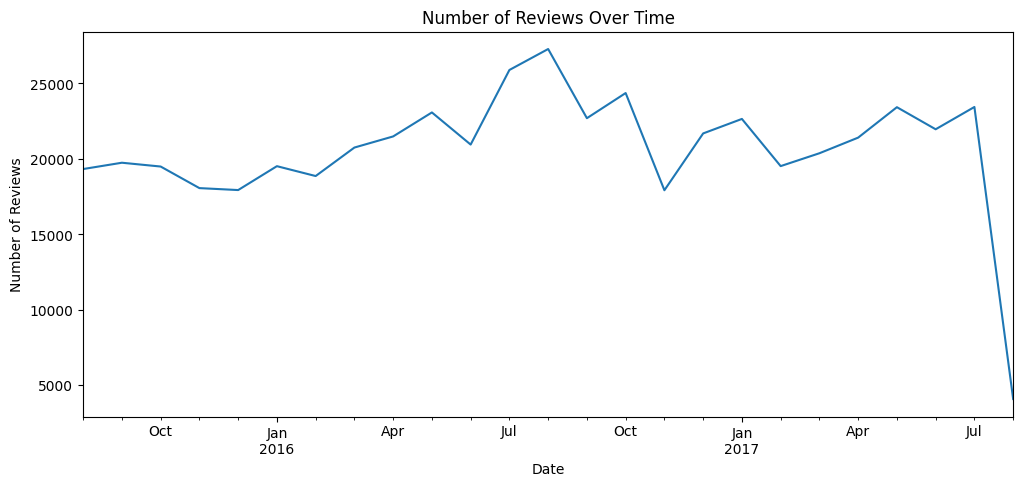

In [ ]:
#14. Reviews Over Time
df["Review_Date"] = pd.to_datetime(df["Review_Date"])
monthly_reviews = (
    df.set_index("Review_Date")
      .resample("ME")
      .size()
)
plt.figure(figsize=(12,5))

monthly_reviews.plot()

plt.title("Number of Reviews Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Reviews")

plt.show()

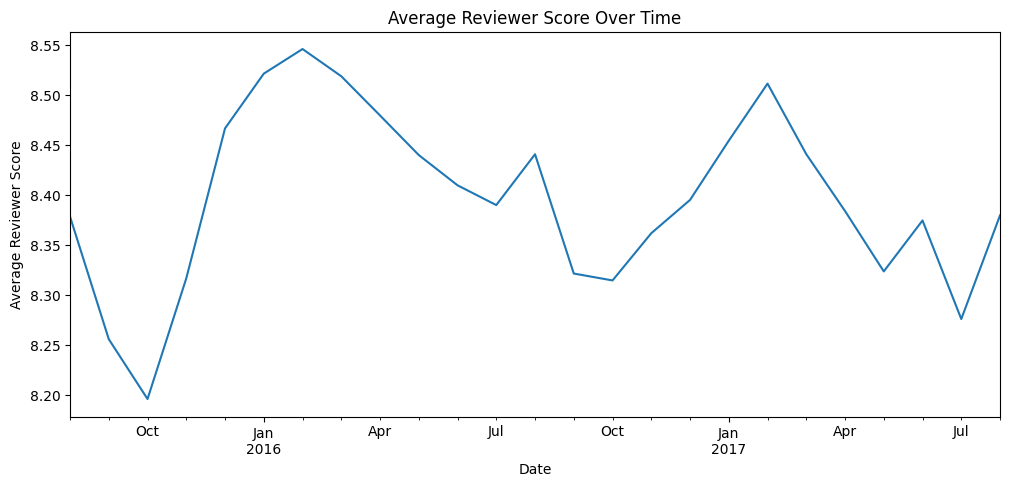

In [ ]:
#15. Average Reviewer Score Over Time
monthly_score = (
    df.set_index("Review_Date")["Reviewer_Score"]
      .resample("ME")
      .mean()
)
plt.figure(figsize=(12,5))

monthly_score.plot()

plt.title("Average Reviewer Score Over Time")
plt.xlabel("Date")
plt.ylabel("Average Reviewer Score")

plt.show()

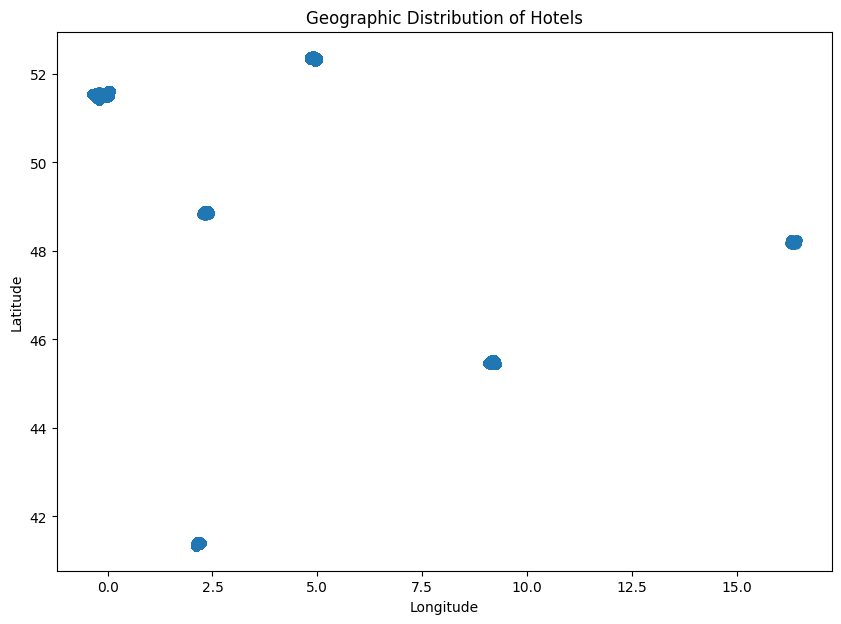

In [ ]:
plt.figure(figsize=(10,7))

plt.scatter(
    df["lng"],
    df["lat"],
    alpha=0.2
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographic Distribution of Hotels")

plt.show()

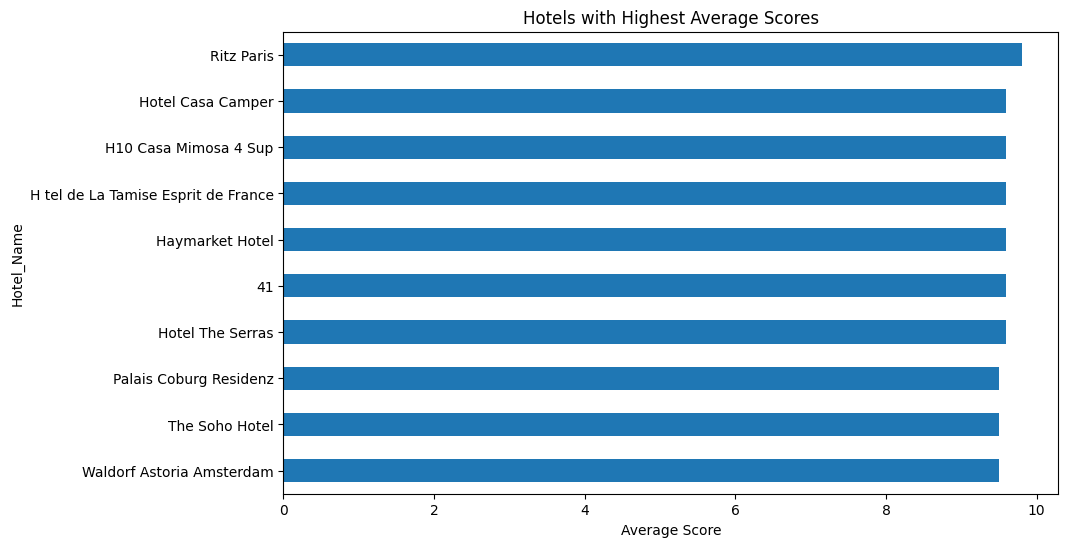

In [ ]:
#Average Score by Hotel — Top/Bottom
hotel_scores = (
    df.groupby("Hotel_Name")["Average_Score"]
      .first()
      .sort_values(ascending=False)
)
hotel_scores.head(10).sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Hotels with Highest Average Scores")
plt.xlabel("Average Score")

plt.show()

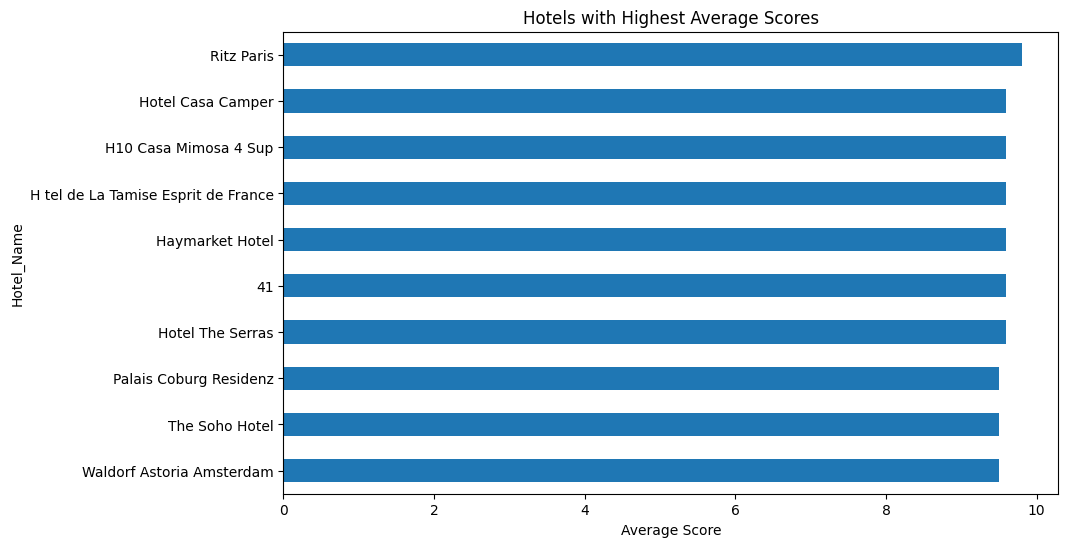

In [ ]:
hotel_scores.head(10).sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Hotels with Highest Average Scores")
plt.xlabel("Average Score")

plt.show()

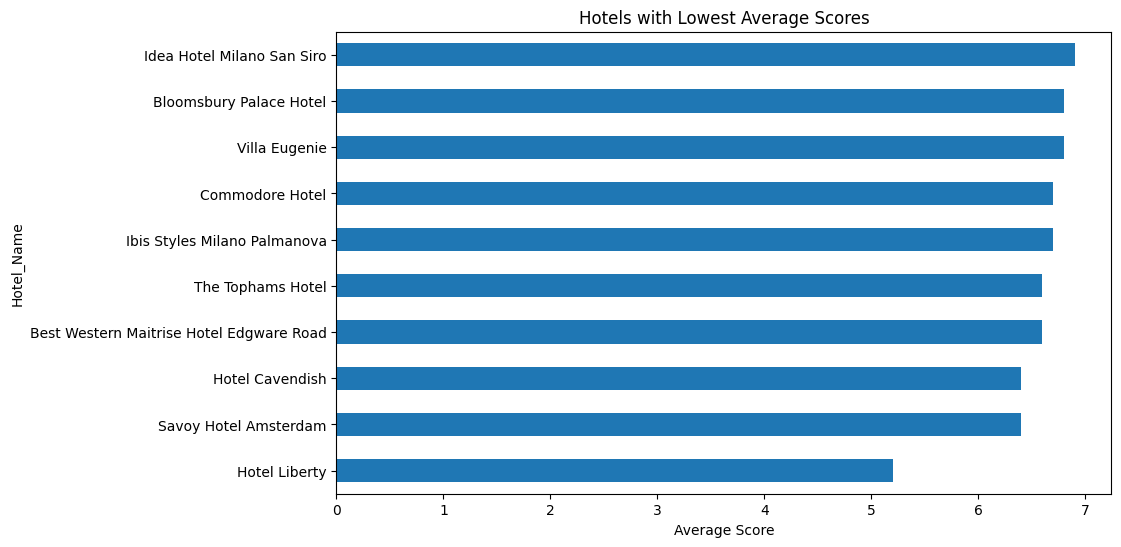

In [ ]:
hotel_scores.tail(10).sort_values().plot(
    kind="barh",
    figsize=(10,6)
)

plt.title("Hotels with Lowest Average Scores")
plt.xlabel("Average Score")

plt.show()